In [81]:
import torch
from utils import solve_riccati
import numpy as np
from network import ScoreNetwork
from utils import batched_jacobian, rollout, non_adapted_adjoint
import matplotlib.pyplot as plt

In [82]:
import matplotlib

plt.rc('font', size = 14)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [83]:
T = 2.0  # End time
n = 2    # Dimension of state space
m = 2    # Dimension of Brownian motion
N = 2000 # Number of training samples
dt = 0.05  # Time step size
steps = int(T/dt)  # Number of time steps
noise_level = 1  # Noise level in the SDE

In [84]:
def f(x, t, u_t=None):
    """
    Drift function of X_t for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    A = torch.tensor([[0.0, 1.0], [-1.0, -0.5]])  # stable 
    return x @ A.T

def g(x):
    """
    Diffusion function of X_t for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[1.0, 0.0], [0.0, 1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

def lf(x):
    """
    Terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Terminal cost. Shape (N,)
    """
    Q_f = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
    return 0.5 * ((x @ Q_f) * x).sum(dim=1)

In [85]:
# Ground truth solution via Riccati equation
A = np.array([[0.0, 1.0], [-1.0, -0.5]])
Q_f = np.array([[1.0, 0.0], [0.0, 1.0]])
G_ref = solve_riccati(A, Q_f, T, dt, dim=2)

In [86]:
phi_net = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=32, num_blocks=2)
phi_net.load_state_dict(torch.load('network/phi_network_linear_nl1_samplenum2000.pth',weights_only=True))
# phi_net.eval()

<All keys matched successfully>

Optimize on initial point

iteration    0 | autograd loss 3665.76 | phi loss 3665.76
iteration  500 | autograd loss 3325.35 | phi loss 3165.91
iteration 1000 | autograd loss 3193.51 | phi loss 3013.08
iteration 1500 | autograd loss 3039.07 | phi loss 2881.83
iteration 2000 | autograd loss 3046.62 | phi loss 2929.86
iteration 2500 | autograd loss 2863.25 | phi loss 2771.94
iteration 3000 | autograd loss 2941.31 | phi loss 2860
iteration 3500 | autograd loss 2843.98 | phi loss 2785.82
iteration 4000 | autograd loss 2837 | phi loss 2803.47
iteration 4500 | autograd loss 2746.19 | phi loss 2731.56

Final:
autograd: loss=2839.29
phi     : loss=2821.08


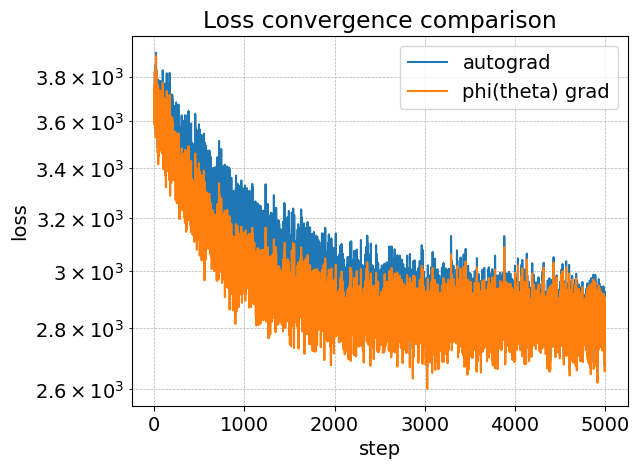

In [87]:
theta0 = torch.randn((N, n))

theta_auto = theta0.clone().detach().requires_grad_(True)
theta_phi  = theta0.clone().detach().requires_grad_(True)

opt_auto = torch.optim.Adam([theta_auto], lr=1e-3)
opt_phi  = torch.optim.Adam([theta_phi],  lr=1e-3)

loss_hist_auto = []
loss_hist_phi  = []
theta_hist_auto = []
theta_hist_phi  = []
theta_hist_auto.append(theta_auto.detach().clone())
theta_hist_phi.append(theta_phi.detach().clone())
for i in range(5000):
    W_f = torch.randn((steps, N, m)) * np.sqrt(dt)  # Brownian increments for forward rollout

    # ======== Method A: autograd ========
    opt_auto.zero_grad(set_to_none=True)

    # compute loss (keep exactly same code path)
    xT_auto = rollout(f, g, T, dt, theta_auto, W_f)[-1]
    loss_auto = lf(xT_auto).sum(dim=0)
    loss_auto.backward()
    opt_auto.step()

    # ======== Method B: custom phi gradient ========
    opt_phi.zero_grad(set_to_none=True)

    # compute loss for logging only 
    with torch.no_grad():
        xT_phi = rollout(f, g, T, dt, theta_phi, W_f)[-1]
        loss_phi = lf(xT_phi).sum(dim=0)

    with torch.no_grad():
        ghat = phi_net(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1))  # shape (N, n)
        theta_phi.grad = ghat.detach()
    opt_phi.step()

    # ---- log ----
    loss_hist_auto.append(loss_auto.detach().item() if loss_auto.numel()==1 else loss_auto.detach().sum().item())
    loss_hist_phi.append(loss_phi.detach().item()  if loss_phi.numel()==1  else loss_phi.detach().sum().item())

    theta_hist_auto.append(theta_auto.detach().clone())
    theta_hist_phi.append(theta_phi.detach().clone())

    # optional: print occasionally
    if i % max(1, 500) == 0:
        print(f"iteration {i:4d} | autograd loss {loss_hist_auto[-1]:.6g} | phi loss {loss_hist_phi[-1]:.6g}")

# ---- final report ----
print("\nFinal:")
print(f"autograd: loss={loss_hist_auto[-1]:.6g}")
print(f"phi     : loss={loss_hist_phi[-1]:.6g}")

# ---- plot ----
plt.figure()
plt.plot(loss_hist_auto, label="autograd")
plt.plot(loss_hist_phi,  label="phi(theta) grad")
plt.yscale("log")  # often helpful; remove if you prefer linear
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Loss convergence comparison")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

(-2.0, 2.0)

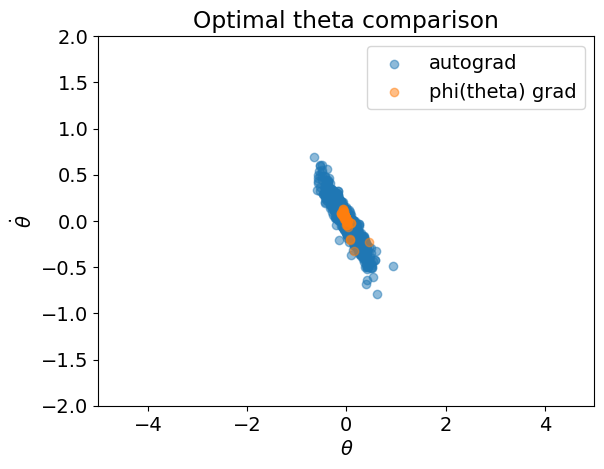

In [88]:
plt.figure()
plt.scatter(theta_auto[:,0].detach().numpy(), theta_auto[:,1].detach().numpy(), label="autograd", alpha=0.5)
plt.scatter(theta_phi[:,0].detach().numpy(), theta_phi[:,1].detach().numpy(), label="phi(theta) grad", alpha=0.5)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\dot{\theta}$")
plt.legend()
plt.title("Optimal theta comparison")
plt.xlim([-5,5])
plt.ylim([-2,2])

In [89]:
nx, ny = 150, 150
# create a grid of points

x = torch.linspace(-5.0, 5.0, nx)
y = torch.linspace(-5.0, 5.0, ny)

# meshgrid
X, Y = torch.meshgrid(x, y, indexing='ij')  # shapes (nx, ny)

theta_grid = torch.stack((X, Y), dim=2).reshape(-1, 2)  # shape (nx*ny, 2)

In [90]:
exp_num = 10000
loss_vec = torch.zeros((theta_grid.shape[0], 1))
for exp_i in range(exp_num):
    
        # generate noise
    # W_f = torch.zeros((steps+1, theta_hist_phi_vec.shape[0], m))# forward noise
    # for noise_step in range(steps+1):
    #     # print(noise_step)
    #     W_f[noise_step, :, :] = noise(dt, theta_hist_phi_vec.shape[0], m)
    W_f = torch.randn(steps + 1, theta_grid.shape[0], m) * torch.sqrt(torch.tensor(dt))
    
    loss_vec += lf(rollout(f, g, T, dt, theta_grid, W_f)[-1]).unsqueeze(-1) # shape (N, 1)
    

    if exp_i % 100 == 0:
        print(f"experiment {exp_i}/{exp_num} done.")

loss_vec /= exp_num  # shape (N, 1)

experiment 0/10000 done.
experiment 100/10000 done.
experiment 200/10000 done.
experiment 300/10000 done.
experiment 400/10000 done.
experiment 500/10000 done.
experiment 600/10000 done.
experiment 700/10000 done.
experiment 800/10000 done.
experiment 900/10000 done.
experiment 1000/10000 done.
experiment 1100/10000 done.
experiment 1200/10000 done.
experiment 1300/10000 done.
experiment 1400/10000 done.
experiment 1500/10000 done.
experiment 1600/10000 done.
experiment 1700/10000 done.
experiment 1800/10000 done.
experiment 1900/10000 done.
experiment 2000/10000 done.
experiment 2100/10000 done.
experiment 2200/10000 done.
experiment 2300/10000 done.
experiment 2400/10000 done.
experiment 2500/10000 done.
experiment 2600/10000 done.
experiment 2700/10000 done.
experiment 2800/10000 done.
experiment 2900/10000 done.
experiment 3000/10000 done.
experiment 3100/10000 done.
experiment 3200/10000 done.
experiment 3300/10000 done.
experiment 3400/10000 done.
experiment 3500/10000 done.
expe

In [91]:
loss_grid = loss_vec.reshape(nx,ny)

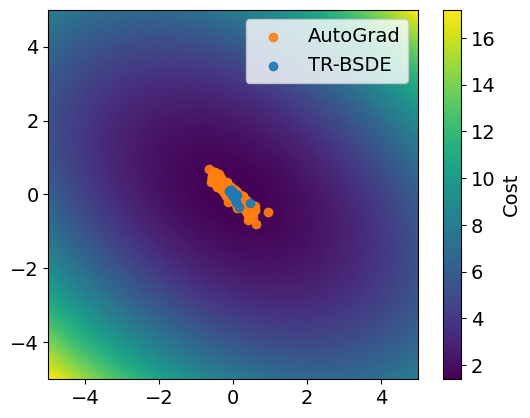

In [92]:
plt.figure()
im = plt.imshow(
    loss_grid.T,                          # transpose for correct orientation
    extent=[-5, 5, -5, 5],
    origin='lower',
)
plt.scatter(theta_auto[:,0].detach().numpy(), theta_auto[:,1].detach().numpy(), label="AutoGrad", alpha=0.9, color='C1')
plt.scatter(theta_phi[:,0].detach().numpy(), theta_phi[:,1].detach().numpy(), label="TR-BSDE", alpha=0.9, color='C0')
plt.colorbar(im, label="Cost")
plt.legend()
# plt.title('Heatmap of f(x, y)')
# plt.show()
plt.savefig("figs/linear_example_loss_landscape.pdf", bbox_inches='tight')

Y_0 Mean square error with respect to noise level

In [93]:
## Adjoint matching dynamics
def adjoint_dyn(x, t):
    """
    Dynamics for the non-adapted adjoint process.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
        y (torch.Tensor): Costate vector. Shape (N, n)
        z (torch.Tensor): Second order term in BSDE. Shape (N, n, m)
        t (torch.Tensor): Current time. Shape (1,)
        u (torch.Tensor): Open-loop control inputs at each time step. Shape (steps, m)
    Returns:
        cost_term (torch.Tensor): Running cost term. Shape (N, n)
        lag_term_mat (torch.Tensor): Lagrange term y^T f_x. Shape (N, n, n)
    """
    A = torch.tensor([[0.0, 1.0], [-1.0, -0.5]])  # stable
    cost_term = torch.zeros_like(x)  # shape (N, n)
    lag_term_mat = (A.T).repeat(x.shape[0], 1, 1)  # shape (N, n, n)
    return cost_term, lag_term_mat

def partial_lf(x):
    """
    Gradient of the terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Gradient of the terminal cost. Shape (N, n)
    """
    Q_f = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
    return x @ Q_f

In [94]:
X_0 = torch.randn((N, n))
G0 = G_ref[:,:,0]
Y_0_gt = X_0 @ G0 # shape (N, n)
nl_list = [0, 0.5, 1, 2, 5]
MSE_auto_list = []
MSE_adjoint_list = []
MSE_TRBSDE_list = []

for nl in nl_list:
    def g(x):
        """
        Diffusion function of X_t for a linear system.
        Args:
            x (torch.Tensor): State vector. Shape (N, n)
        Returns:
            torch.Tensor: Diffusion matrix. Shape (N, n, m)
        """
        B = torch.tensor([[1.0, 0.0], [0.0, 1.0]]) * nl
        B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
        return B
    
    W_f = torch.randn((steps, N, m)) * np.sqrt(dt)  # Brownian increments for forward rollout
    ## Auto Gradient method 
    theta_auto = X_0.clone().detach().requires_grad_(True)
    loss = lf(rollout(f, g, T, dt, theta_auto, W_f)[-1, :, :]).sum(dim=0)
    Y0_auto = torch.autograd.grad(loss.sum(), theta_auto)[0] # shape (N, n)

    ## Adjoint Matching method
    theta_adjoint = X_0.clone().detach()
    X_f = rollout(f, g, T, dt, theta_adjoint, W_f)
    X_T = X_f[-1, :, :] # shape (N, n)
    Y_T = partial_lf(X_T)  # shape (N, n)
    Y_b = non_adapted_adjoint(adjoint_dyn, X_f, T, dt, Y_T).detach()  # shape (steps+1, N, n)
    Y0_adjoint = Y_b[0,:,:]

    ## TR-BSDE method
    phi_net.load_state_dict(torch.load(f'network/phi_network_linear_nl{nl}_samplenum2000.pth',weights_only=True))
    theta_phi = X_0.clone().detach()
    Y0_TRBSDE = phi_net(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1)).detach()


    ## Compute MSE
    MSE_auto = ((Y0_auto - Y_0_gt)**2).sum(dim=1).mean().item()
    MSE_adjoint = ((Y0_adjoint - Y_0_gt)**2).sum(dim=1).mean().item()
    MSE_TRBSDE = ((Y0_TRBSDE - Y_0_gt)**2).sum(dim=1).mean().item()
    MSE_auto_list.append(MSE_auto)
    MSE_adjoint_list.append(MSE_adjoint)
    MSE_TRBSDE_list.append(MSE_TRBSDE)



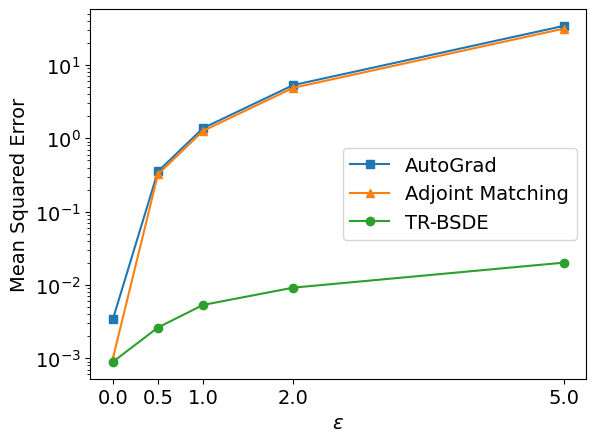

In [95]:
plt.figure()
plt.plot(nl_list, MSE_auto_list, label="AutoGrad", marker='s')
plt.plot(nl_list, MSE_adjoint_list, label="Adjoint Matching", marker='^')
plt.plot(nl_list, MSE_TRBSDE_list, label="TR-BSDE", marker='o')
plt.yscale("log")
plt.xticks(nl_list)
plt.xlabel(r"$\epsilon$")
plt.ylabel("Mean Squared Error")
plt.legend()
# plt.show()
# plt.savefig("figs/linear_example_mse_comparison_noiselevel.pdf", bbox_inches='tight')

Y_0 Mean square error with respect to sample number

In [96]:
noise_level = 1
def g(x):
    """
    Diffusion function of X_t for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[1.0, 0.0], [0.0, 1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

In [101]:
G0 = G_ref[:,:,0]
sample_num_list = [50, 100, 500, 2000, 5000, 10000]
sample_MSE_auto_list = []
sample_MSE_adjoint_list = []
sample_MSE_TRBSDE_list = []

for sample_num in sample_num_list:
    N = sample_num
    X_0 = torch.randn((N, n))
    Y_0_gt = X_0 @ G0 # shape (N, n)
    
    W_f = torch.randn((steps, N, m)) * np.sqrt(dt)  # Brownian increments for forward rollout
    ## Auto Gradient method 
    theta_auto = X_0.clone().detach().requires_grad_(True)
    loss = lf(rollout(f, g, T, dt, theta_auto, W_f)[-1, :, :]).sum(dim=0)
    Y0_auto = torch.autograd.grad(loss.sum(), theta_auto)[0] # shape (N, n)

    ## Adjoint Matching method
    theta_adjoint = X_0.clone().detach()
    X_f = rollout(f, g, T, dt, theta_adjoint, W_f)
    X_T = X_f[-1, :, :] # shape (N, n)
    Y_T = partial_lf(X_T)  # shape (N, n)
    Y_b = non_adapted_adjoint(adjoint_dyn, X_f, T, dt, Y_T).detach()  # shape (steps+1, N, n)
    Y0_adjoint = Y_b[0,:,:]

    ## TR-BSDE method
    phi_net.load_state_dict(torch.load(f'network/phi_network_linear_nl1_samplenum{sample_num}.pth',weights_only=True))
    theta_phi = X_0.clone().detach()
    Y0_TRBSDE = phi_net(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1)).detach()


    ## Compute MSE
    sample_MSE_auto = ((Y0_auto - Y_0_gt)**2).sum(dim=1).mean().item()
    sample_MSE_adjoint = ((Y0_adjoint - Y_0_gt)**2).sum(dim=1).mean().item()
    sample_MSE_TRBSDE = ((Y0_TRBSDE - Y_0_gt)**2).sum(dim=1).mean().item()
    sample_MSE_auto_list.append(sample_MSE_auto)
    sample_MSE_adjoint_list.append(sample_MSE_adjoint)
    sample_MSE_TRBSDE_list.append(sample_MSE_TRBSDE)



In [102]:
def sci_label(x):
    exp = int(np.floor(np.log10(x)))
    mant = int(x / 10**exp)
    
    if mant == 1:
        return rf"$10^{{{exp}}}$"
    else:
        return rf"${mant}\times10^{{{exp}}}$"

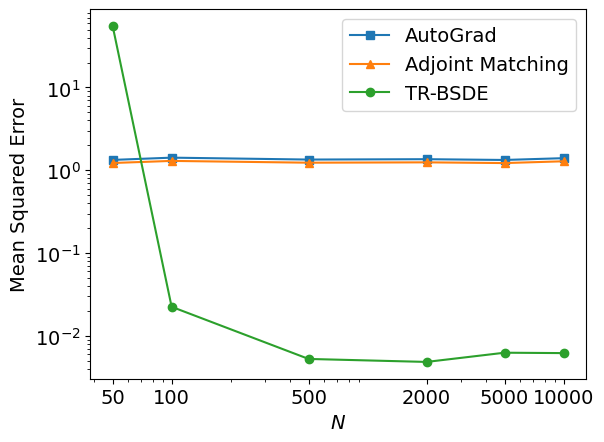

In [103]:
plt.figure()
plt.plot(sample_num_list, sample_MSE_auto_list, label="AutoGrad", marker='s')
plt.plot(sample_num_list, sample_MSE_adjoint_list, label="Adjoint Matching", marker='^')
plt.plot(sample_num_list, sample_MSE_TRBSDE_list, label="TR-BSDE", marker='o')
plt.xscale("log")
plt.yscale("log")
plt.xticks(sample_num_list, [str(x) for x in sample_num_list])
# plt.xticks(sample_num_list, [sci_label(x) for x in sample_num_list])
plt.xlabel(r"$N$")
plt.ylabel("Mean Squared Error")
plt.legend()
# plt.show()
# plt.savefig("figs/linear_example_mse_comparison_samplenum.pdf", bbox_inches='tight')

Compare G0

In [77]:
N = 2000

In [74]:
X_0 = torch.randn((N, n))
G0 = G_ref[:,:,0]
nl_list = [0, 0.5, 1, 2, 5]
GMSE_auto_list = []
GMSE_adjoint_list = []
GMSE_TRBSDE_list = []

for nl in nl_list:
    def g(x):
        """
        Diffusion function of X_t for a linear system.
        Args:
            x (torch.Tensor): State vector. Shape (N, n)
        Returns:
            torch.Tensor: Diffusion matrix. Shape (N, n, m)
        """
        B = torch.tensor([[1.0, 0.0], [0.0, 1.0]]) * nl
        B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
        return B
    
    W_f = torch.randn((steps, N, m)) * np.sqrt(dt)  # Brownian increments for forward rollout
    ## Auto Gradient method 
    theta_auto = X_0.clone().detach().requires_grad_(True)
    loss = lf(rollout(f, g, T, dt, theta_auto, W_f)[-1, :, :]).sum(dim=0)
    Y0_auto = torch.autograd.grad(loss.sum(), theta_auto)[0].detach() # shape (N, n)
    G0_auto = torch.linalg.lstsq(X_0, Y0_auto).solution.T

    ## Adjoint Matching method
    theta_adjoint = X_0.clone().detach()
    X_f = rollout(f, g, T, dt, theta_adjoint, W_f)
    X_T = X_f[-1, :, :] # shape (N, n)
    Y_T = partial_lf(X_T)  # shape (N, n)
    Y_b = non_adapted_adjoint(adjoint_dyn, X_f, T, dt, Y_T).detach()  # shape (steps+1, N, n)
    Y0_adjoint = Y_b[0,:,:]
    G0_adjoint = torch.linalg.lstsq(X_0, Y0_adjoint).solution.T


    ## TR-BSDE method
    phi_net.load_state_dict(torch.load(f'network/phi_network_linear_nl{nl}_samplenum2000.pth',weights_only=True))
    theta_phi = X_0.clone().detach()
    Y0_TRBSDE = phi_net(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1)).detach()
    G0_TRBSDE = torch.linalg.lstsq(X_0, Y0_TRBSDE).solution.T


    ## Compute GMSE
    GMSE_auto = ((G0_auto - G0)**2).sum().item()
    GMSE_adjoint = ((G0_adjoint - G0)**2).sum().item()
    GMSE_TRBSDE = ((G0_TRBSDE - G0)**2).sum().item()
    GMSE_auto_list.append(GMSE_auto)
    GMSE_adjoint_list.append(GMSE_adjoint)
    GMSE_TRBSDE_list.append(GMSE_TRBSDE)



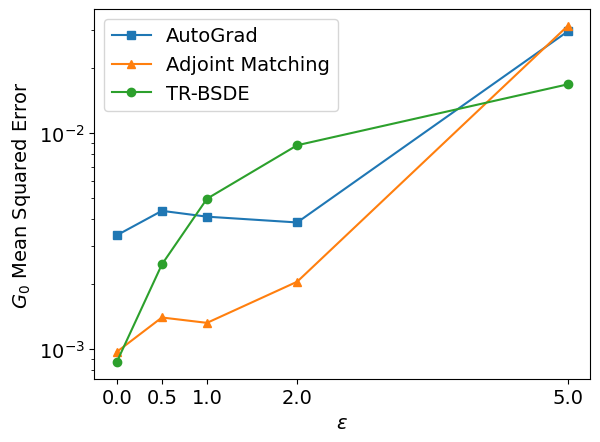

In [75]:
plt.figure()
plt.plot(nl_list, GMSE_auto_list, label="AutoGrad", marker='s')
plt.plot(nl_list, GMSE_adjoint_list, label="Adjoint Matching", marker='^')
plt.plot(nl_list, GMSE_TRBSDE_list, label="TR-BSDE", marker='o')
plt.yscale("log")
plt.xticks(nl_list)
plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$G_0$ Mean Squared Error")
plt.legend()
# plt.show()
# plt.savefig("figs/G_linear_example_mse_comparison_noiselevel.pdf", bbox_inches='tight')

In [76]:
noise_level = 1
def g(x):
    """
    Diffusion function of X_t for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[1.0, 0.0], [0.0, 1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

In [78]:
G0 = G_ref[:,:,0]
sample_num_list = [50, 100, 500, 2000, 5000, 10000]
Gsample_MSE_auto_list = []
Gsample_MSE_adjoint_list = []
Gsample_MSE_TRBSDE_list = []

for sample_num in sample_num_list:
    N = sample_num
    X_0 = torch.randn((N, n))
    
    W_f = torch.randn((steps, N, m)) * np.sqrt(dt)  # Brownian increments for forward rollout
    ## Auto Gradient method 
    theta_auto = X_0.clone().detach().requires_grad_(True)
    loss = lf(rollout(f, g, T, dt, theta_auto, W_f)[-1, :, :]).sum(dim=0)
    Y0_auto = torch.autograd.grad(loss.sum(), theta_auto)[0] # shape (N, n)
    G0_auto = torch.linalg.lstsq(X_0, Y0_auto).solution.T

    ## Adjoint Matching method
    theta_adjoint = X_0.clone().detach()
    X_f = rollout(f, g, T, dt, theta_adjoint, W_f)
    X_T = X_f[-1, :, :] # shape (N, n)
    Y_T = partial_lf(X_T)  # shape (N, n)
    Y_b = non_adapted_adjoint(adjoint_dyn, X_f, T, dt, Y_T).detach()  # shape (steps+1, N, n)
    Y0_adjoint = Y_b[0,:,:]
    G0_adjoint = torch.linalg.lstsq(X_0, Y0_adjoint).solution.T

    ## TR-BSDE method
    phi_net.load_state_dict(torch.load(f'network/phi_network_linear_nl1_samplenum{sample_num}.pth',weights_only=True))
    theta_phi = X_0.clone().detach()
    Y0_TRBSDE = phi_net(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1)).detach()
    G0_TRBSDE = torch.linalg.lstsq(X_0, Y0_TRBSDE).solution.T


    ## Compute MSE
    sample_MSE_auto = ((G0_auto - G0)**2).sum(dim=1).mean().item()
    sample_MSE_adjoint = ((G0_adjoint - G0)**2).sum(dim=1).mean().item()
    sample_MSE_TRBSDE = ((G0_TRBSDE - G0)**2).sum(dim=1).mean().item()
    Gsample_MSE_auto_list.append(sample_MSE_auto)
    Gsample_MSE_adjoint_list.append(sample_MSE_adjoint)
    Gsample_MSE_TRBSDE_list.append(sample_MSE_TRBSDE)

In [79]:
G0, G0_auto, G0_adjoint, G0_TRBSDE

(array([[0.34730027, 0.17095421],
        [0.17095421, 0.47393603]]),
 tensor([[0.3912, 0.1757],
         [0.2067, 0.5212]]),
 tensor([[0.3764, 0.1788],
         [0.1899, 0.4972]]),
 tensor([[0.3283, 0.1194],
         [0.2096, 0.4353]]))

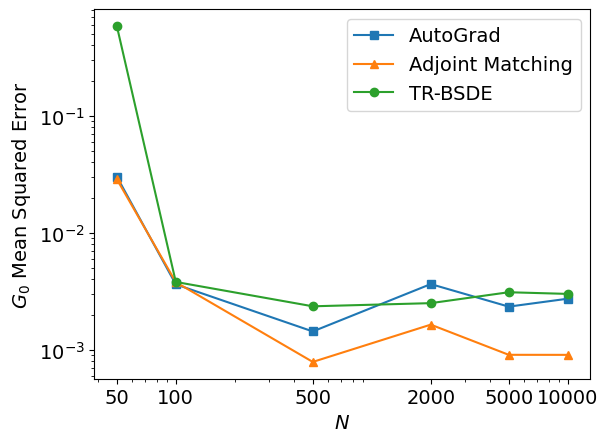

In [80]:
plt.figure()
plt.plot(sample_num_list, Gsample_MSE_auto_list, label="AutoGrad", marker='s')
plt.plot(sample_num_list, Gsample_MSE_adjoint_list, label="Adjoint Matching", marker='^')
plt.plot(sample_num_list, Gsample_MSE_TRBSDE_list, label="TR-BSDE", marker='o')
plt.xscale("log")
plt.yscale("log")
plt.xticks(sample_num_list, [str(x) for x in sample_num_list])
# plt.xticks(sample_num_list, [sci_label(x) for x in sample_num_list])
plt.xlabel(r"$N$")
plt.ylabel(r"$G_0$ Mean Squared Error")
plt.legend()
# plt.show()
# plt.savefig("figs/linear_example_mse_comparison_samplenum.pdf", bbox_inches='tight')